In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the dataset
data = pd.read_csv('/content/data.csv', encoding='ISO-8859-1')

# Preview the dataset
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Remove rows where CustomerID is missing or Quantity is zero or negative
data = data.dropna(subset=['CustomerID', 'Quantity', 'UnitPrice'])
data = data[data['Quantity'] > 0]
data = data[data['UnitPrice'] > 0]

# Convert 'InvoiceDate' to datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

# Preview the cleaned data
data.head()


<ipython-input-3-bd31dae4f5b8>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Calculate TotalSales = Quantity * UnitPrice
data['TotalSales'] = data['Quantity'] * data['UnitPrice']

# Frequency: Number of unique purchases per customer
frequency = data.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',  # Number of unique invoices (purchases)
}).rename(columns={'InvoiceNo': 'Frequency'})

# Monetary: Total sales per customer
monetary = data.groupby('CustomerID').agg({
    'TotalSales': 'sum',  # Sum of total sales per customer
}).rename(columns={'TotalSales': 'Monetary'})

# Recency: Time since last purchase
recency = data.groupby('CustomerID').agg({
    'InvoiceDate': 'max',  # Most recent purchase date
}).rename(columns={'InvoiceDate': 'Recency'})

# Merge all features into one dataframe
customer_data = pd.merge(frequency, monetary, on='CustomerID')
customer_data = pd.merge(customer_data, recency, on='CustomerID')

# Calculate Recency in days (time since last purchase)
current_date = data['InvoiceDate'].max()
customer_data['Recency'] = (current_date - customer_data['Recency']).dt.days

# Preview the customer data
customer_data.head()


,Frequency,Monetary,Recency
CustomerID,,,
12346.0,1,77183.60,325
12347.0,7,4310.00,1
12348.0,4,1797.24,74
12349.0,1,1757.55,18
12350.0,1,334.40,309


In [ ]:
# Normalize the data using StandardScaler
scaler = StandardScaler()
customer_data_scaled = scaler.fit_transform(customer_data[['Recency', 'Frequency', 'Monetary']])

# Preview the scaled data
customer_data_scaled[:5]


array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

In [ ]:
# Apply KMeans Clustering (Let's assume 5 clusters based on the Elbow method)
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(customer_data_scaled)

# Preview the clusters
customer_data.head()


,Frequency,Monetary,Recency,Cluster
CustomerID,,,,
12346.0,1,77183.60,325,2
12347.0,7,4310.00,1,0
12348.0,4,1797.24,74,0
12349.0,1,1757.55,18,0
12350.0,1,334.40,309,1


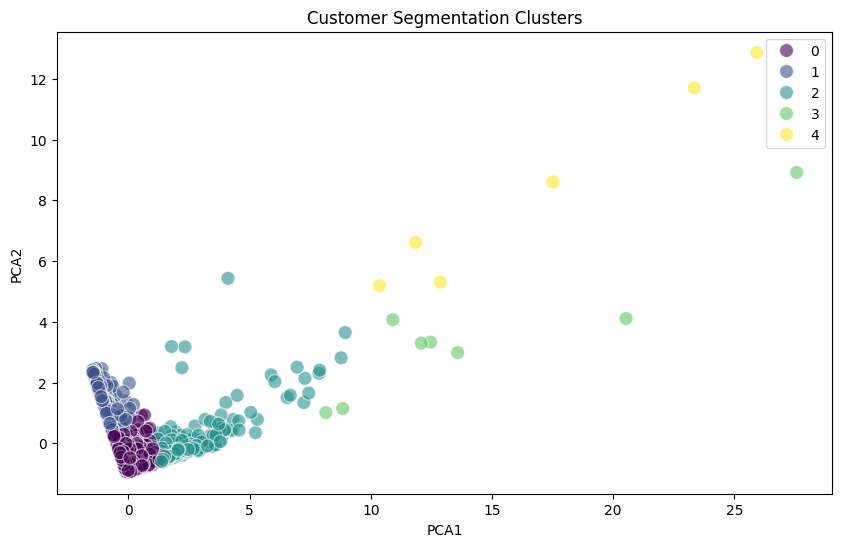

In [ ]:
# PCA for Dimensionality Reduction and Visualization
from sklearn.decomposition import PCA

# Perform PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(customer_data_scaled)

# Add PCA components and cluster information to the dataframe
customer_data['PCA1'] = pca_components[:, 0]
customer_data['PCA2'] = pca_components[:, 1]

# Plotting the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_data, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', s=100, alpha=0.6)
plt.title('Customer Segmentation Clusters')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.legend()
plt.show()


In [ ]:
# Analyze the clusters
cluster_summary = customer_data.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
}).reset_index()

# Display the summary of clusters
print(cluster_summary)


   Cluster     Recency   Frequency       Monetary
0        0   42.952771    3.650049    1339.066659
1        1  247.564030    1.551789     478.107581
2        2   14.671362   21.286385   12831.742488
3        3    5.500000  120.500000   55312.686250
4        4    6.666667   42.833333  190863.461667
